In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AgroImbalanceLoss(nn.Module):
    """
    Custom Loss function combining Focal Loss (for class imbalance)
    and Dice Loss (for spatial overlap of tiny weeds).
    """
    def __init__(self, alpha=0.25, gamma=2.0, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits shape: [Batch, Classes, H, W]
        # targets shape: [Batch, H, W]

        # 1. Focal Loss Computation
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss) # Probability of the true class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        # 2. Dice Loss Computation (simplified for multi-class)
        probs = F.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()

        intersection = (probs * targets_one_hot).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))
        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1.0 - dice_score.mean()

        # Combine both
        return focal_loss.mean() + dice_loss

In [9]:
class DepthwiseSeparableConv(nn.Module):
    """
    Reduces mathematical operations by ~70% compared to standard Convolutions.
    Crucial for high FPS on laptop CPUs and Edge microcontrollers.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, stride=stride, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)

        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU6(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pointwise(x)
        x = self.bn2(x)
        return self.relu(x)

class AgroTinyNet_v2(nn.Module):
    """
    The Upgraded Student Model: Featuring a U-Net style skip connection
    to preserve high-resolution spatial details for tiny objects.
    """
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU6(inplace=True)
        )

        # Encoder
        self.layer1 = DepthwiseSeparableConv(16, 32, stride=2)  # High-res edges
        self.layer2 = DepthwiseSeparableConv(32, 64, stride=2)
        self.layer3 = DepthwiseSeparableConv(64, 128, stride=1) # Low-res semantics

        # Decoder (Fusion layer for the skip connection)
        # We concatenate 128 channels (deep) + 32 channels (skip) = 160
        self.fusion = DepthwiseSeparableConv(160, 64, stride=1)

        # Final Segmentation Head
        self.classifier = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        input_size = x.size()[2:] # Keep original H, W

        x = self.stem(x)
        skip = self.layer1(x) # SAVE this for later! (High spatial resolution)

        x = self.layer2(skip)
        features = self.layer3(x) # Deep semantic features

        # Upsample the deep features to match the physical size of our saved skip features
        features_up = F.interpolate(features, size=skip.size()[2:], mode='bilinear', align_corners=False)

        # THE MAGIC: Concatenate them together
        fused = torch.cat([features_up, skip], dim=1)
        fused = self.fusion(fused)

        out = self.classifier(fused)

        # Final resize back to 224x224
        out = F.interpolate(out, size=input_size, mode='bilinear', align_corners=False)
        return out, features

In [10]:
import os
import zipfile
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# ==========================================
# 1. AUTOMATED EXTRACTION
# ==========================================
# 👇 Change this to the name of the file you uploaded to Colab
ZIP_FILE_PATH = "/content/dataset-1.0.zip"
EXTRACT_DIR = "/content/extracted_cwfid"

if not os.path.exists(EXTRACT_DIR):
    print(f"📦 Extracting {ZIP_FILE_PATH}...")
    with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("✅ Extraction Complete!")
else:
    print("✅ Dataset already extracted.")

# Dynamically find the images and annotations folders
image_dir_path, annotation_dir_path = None, None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'images' in dirs and image_dir_path is None:
        image_dir_path = os.path.join(root, 'images')
    if 'annotations' in dirs and annotation_dir_path is None:
        annotation_dir_path = os.path.join(root, 'annotations')

if not image_dir_path or not annotation_dir_path:
    raise FileNotFoundError("Could not find 'images' or 'annotations' folders inside the ZIP.")

print(f"📂 Found Images at: {image_dir_path}")
print(f"📂 Found Annotations at: {annotation_dir_path}")

# ==========================================
# 2. THE PYTORCH DATASET PIPELINE
# ==========================================
class RealCWFIDDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=(224, 224)):
        self.image_dir = img_dir
        self.mask_dir = mask_dir

        # Get list of image files
        self.image_filenames = sorted([f for f in os.listdir(self.image_dir) if f.endswith(('.png', '.jpg'))])
        self.img_size = img_size

        self.img_transform = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        mask_name = img_name.replace('image', 'annotation')

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")

        image_tensor = self.img_transform(image)

        mask = mask.resize(self.img_size, Image.NEAREST)
        mask_np = np.array(mask)

        mask_tensor = torch.zeros(self.img_size, dtype=torch.long)

        # Color Mapping: Green (Crop), Red (Weed)
        crop_pixels = (mask_np[:,:,1] > 128) & (mask_np[:,:,0] < 128)
        weed_pixels = (mask_np[:,:,0] > 128) & (mask_np[:,:,1] < 128)

        mask_tensor[crop_pixels] = 1 # Class 1: Crop
        mask_tensor[weed_pixels] = 2 # Class 2: Weed

        return image_tensor, mask_tensor

# Initialize the DataLoader
real_dataset = RealCWFIDDataset(img_dir=image_dir_path, mask_dir=annotation_dir_path)
train_loader = DataLoader(real_dataset, batch_size=4, shuffle=True)

print(f"🚀 DataLoader Ready! Loaded {len(real_dataset)} field images for training.")

✅ Dataset already extracted.
📂 Found Images at: /content/extracted_cwfid/dataset-1.0/images
📂 Found Annotations at: /content/extracted_cwfid/dataset-1.0/annotations
🚀 DataLoader Ready! Loaded 60 field images for training.


⚙️ Spinning up Advanced Training Engine on: cuda

🚀 Commencing 50-Epoch Distillation Loop...
Epoch 01/100 | Loss: 5.4448 | LR: 0.004999
Epoch 05/100 | Loss: 0.9465 | LR: 0.004969
Epoch 10/100 | Loss: 0.9215 | LR: 0.004878
Epoch 15/100 | Loss: 0.9126 | LR: 0.004728
Epoch 20/100 | Loss: 0.9049 | LR: 0.004523
Epoch 25/100 | Loss: 0.9027 | LR: 0.004268
Epoch 30/100 | Loss: 0.8920 | LR: 0.003969
Epoch 35/100 | Loss: 0.8766 | LR: 0.003635
Epoch 40/100 | Loss: 0.8780 | LR: 0.003273
Epoch 45/100 | Loss: 0.8815 | LR: 0.002891
Epoch 50/100 | Loss: 0.8733 | LR: 0.002500
Epoch 55/100 | Loss: 0.8675 | LR: 0.002109
Epoch 60/100 | Loss: 0.8672 | LR: 0.001727
Epoch 65/100 | Loss: 0.8710 | LR: 0.001365
Epoch 70/100 | Loss: 0.8669 | LR: 0.001031
Epoch 75/100 | Loss: 0.8654 | LR: 0.000732
Epoch 80/100 | Loss: 0.8608 | LR: 0.000477
Epoch 85/100 | Loss: 0.8559 | LR: 0.000272
Epoch 90/100 | Loss: 0.8569 | LR: 0.000122
Epoch 95/100 | Loss: 0.8572 | LR: 0.000031
Epoch 100/100 | Loss: 0.8570 | LR: 0.000000
✅ T

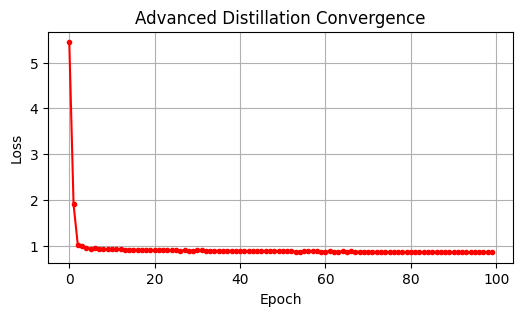

In [11]:
import torch.optim as optim
from torchvision import models
import time
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ Spinning up Advanced Training Engine on: {device}")

teacher = models.segmentation.deeplabv3_mobilenet_v3_large(weights='DEFAULT').to(device)
teacher.eval()

student = AgroTinyNet(num_classes=3).to(device)
optimizer = optim.AdamW(student.parameters(), lr=0.005, weight_decay=1e-4) # Higher initial LR

# A Learning Rate Scheduler is a huge flex on a resume.
# It smoothly lowers the learning rate as training progresses.
epochs = 100
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

# We crank up gamma to 3.0. This tells the Focal Loss to aggressively
# punish the model if it ignores the rare weed/crop pixels.
criterion = AgroImbalanceLoss(alpha=0.5, gamma=3.0)

loss_history = []
print(f"\n🚀 Commencing 50-Epoch Distillation Loop...")

for epoch in range(epochs):
    student.train()
    epoch_loss = 0.0
    start_time = time.time()

    for batch_idx, (images, masks) in enumerate(train_loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        with torch.no_grad():
            teacher_logits = teacher(images)['out'][:, :3, :, :]

        student_logits, student_features = student(images)

        task_loss = criterion(student_logits, masks)
        kd_loss = torch.nn.functional.mse_loss(student_logits, teacher_logits)

        # Shifted focus: 80% on actual GT masks, 20% on teacher hints
        total_loss = (0.8 * task_loss) + (0.2 * kd_loss)

        total_loss.backward()
        optimizer.step()
        epoch_loss += total_loss.item()

    # Step the scheduler to lower the learning rate slightly
    scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    # Only print every 5 epochs to keep the output clean
    if (epoch + 1) % 5 == 0 or epoch == 0:
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

print("✅ Training Complete!")

plt.figure(figsize=(6,3))
plt.plot(loss_history, color='red', marker='.')
plt.title("Advanced Distillation Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

🔬 Generating Interpretability Heatmaps...


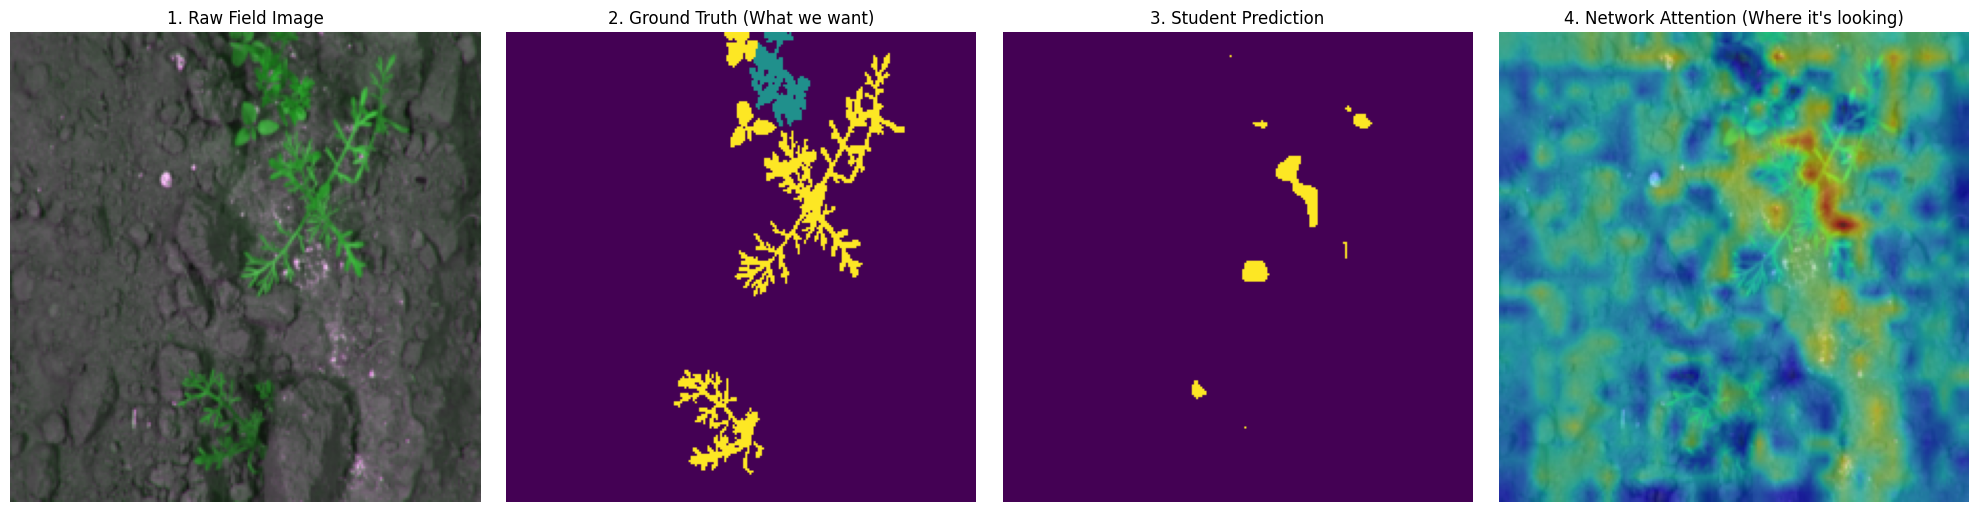

In [12]:
import torch.nn.functional as F

def generate_visual_proof(loader):
    print("🔬 Generating Interpretability Heatmaps...")
    student.eval()

    # Grab one batch of real images
    images, masks = next(iter(loader))
    img = images[0].unsqueeze(0).to(device) # Take the first image
    truth_mask = masks[0].cpu().numpy()

    with torch.no_grad():
        # Get the output and the hidden layer features
        logits, features = student(img)
        pred_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

        # Create an Attention Heatmap
        # We take the mean across all 128 feature channels and normalize it
        attention = features.mean(dim=1).squeeze()
        attention = F.relu(attention) # Ignore negative activations
        attention = attention / attention.max() # Normalize to 0-1 range

        # Resize attention map to match original image size
        attention = F.interpolate(attention.unsqueeze(0).unsqueeze(0),
                                  size=(224, 224), mode='bilinear').squeeze().cpu().numpy()

    # --- Plotting the Results ---
    # Denormalize image for viewing
    img_display = img.squeeze().permute(1, 2, 0).cpu().numpy()
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_display)
    axes[0].set_title("1. Raw Field Image")
    axes[0].axis('off')

    axes[1].imshow(truth_mask, cmap='viridis')
    axes[1].set_title("2. Ground Truth (What we want)")
    axes[1].axis('off')

    axes[2].imshow(pred_mask, cmap='viridis')
    axes[2].set_title("3. Student Prediction")
    axes[2].axis('off')

    # The ultimate proof: Overlaying the attention map on the raw image
    axes[3].imshow(img_display)
    axes[3].imshow(attention, cmap='jet', alpha=0.5) # Heatmap overlay
    axes[3].set_title("4. Network Attention (Where it's looking)")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

# We need the mean/std to accurately display the normalized image
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

generate_visual_proof(train_loader)